# Encoder–Decoder Architecture for Sequence-to-Sequence Data

## 1. Background Journey
Neural networks evolved in stages based on the type of data and challenges:

- **Stage 1: Tabular Data**
  - Simple CSV/Excel style data (e.g., student CGPA, IQ → placement prediction).
  - Models used: **Artificial Neural Networks (ANNs)** and **Deep Neural Networks (DNNs)**.

- **Stage 2: Image Data**
  - Images represented as grids of pixels with spatial meaning.
  - ANNs failed to capture spatial structure → need for **Convolutional Neural Networks (CNNs)**.

- **Stage 3: Sequential Data**
  - Data where order matters (e.g., text, speech, time series).
  - ANNs and CNNs could not handle sequence order effectively.
  - Solution: **Recurrent Neural Networks (RNNs)** and their variants **LSTMs** and **GRUs**.

- **Stage 4: Sequence-to-Sequence (Seq2Seq) Data**
  - Both input and output are sequences.
  - Example: **Machine Translation**
    - Input: “Nice to meet you” (English)
    - Output: “आपसे मिलकर अच्छा लगा” (Hindi)

---

## 2. Challenges in Seq2Seq Data
1. **Variable Input Length**
   - Sentences can be 2 words or 200 words.

2. **Variable Output Length**
   - Translations or responses may have different lengths than inputs.

3. **No One-to-One Word Mapping**
   - Example: English sentence has 4 words, Hindi translation may have 6 words.

Thus, the main difficulty is handling **variable-length input and output sequences** simultaneously.

---

## 3. Encoder–Decoder Architecture
- Proposed in the landmark 2014 paper *“Sequence to Sequence Learning with Neural Networks”* by **Ilya Sutskever et al.**
- Motivation:
  - LSTMs/GRUs could handle variable input length but not variable output length.
  - Encoder–Decoder extends this by enabling both input and output sequence handling.

### Working Idea
- **Encoder**: Reads the input sequence and encodes it into a fixed-size vector (context).
- **Decoder**: Takes this vector and generates the output sequence step by step.

---

## 4. Why It Matters
- Encoder–Decoder is the **foundation** for modern NLP.
- Even though today’s models (e.g., Transformers, LLMs) dominate, this architecture provides:
  - The conceptual base for **attention mechanisms**.
  - A stepping stone towards understanding **Transformers and LLMs**.

---



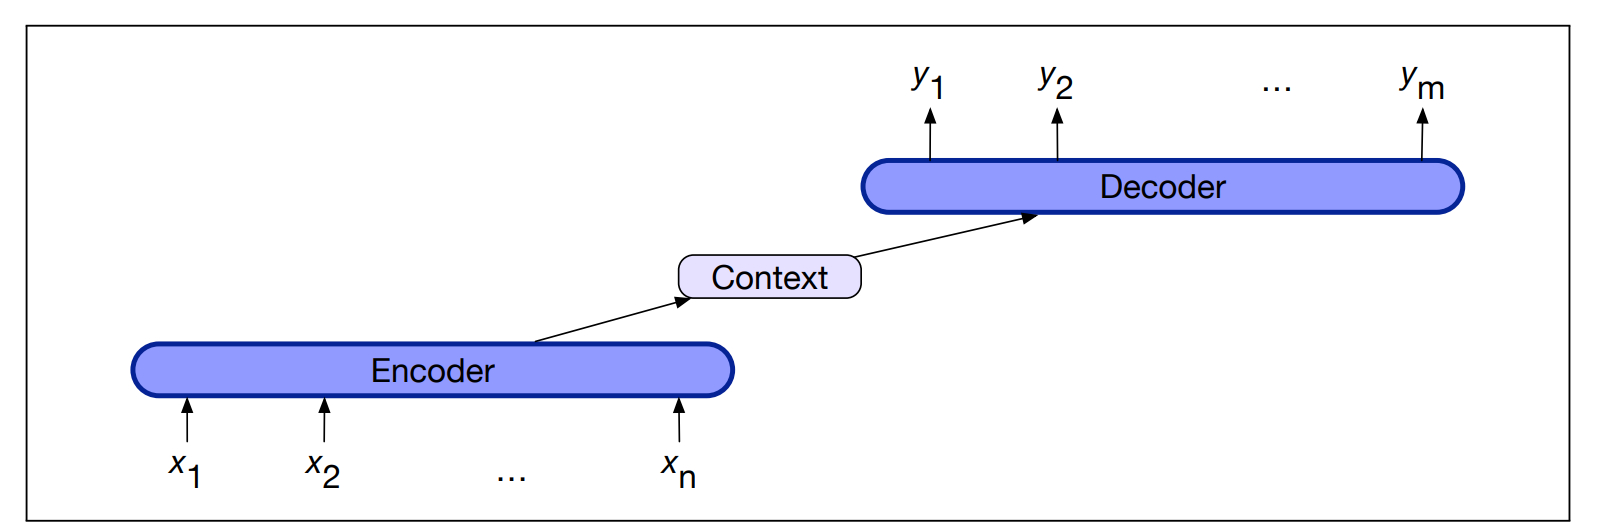

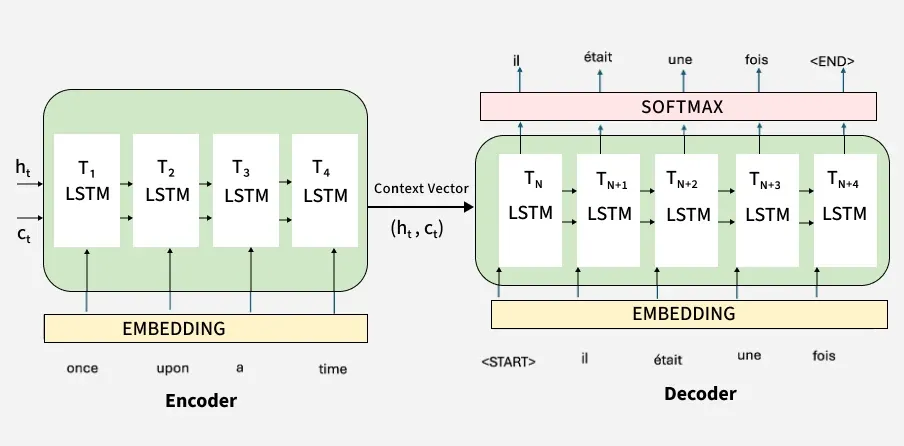

# Encoder–Decoder Architecture (Detailed Working)

## Running Example: Machine Translation
Throughout this explanation, we use **English → Hindi translation** as the running example.  
- Input: "Nice to meet you"  
- Output: "आपसे मिलकर अच्छा लगा"  

---

## High-Level Overview
The architecture consists of **two main blocks**:
1. **Encoder** – Processes the input sequence.
2. **Decoder** – Generates the output sequence.
3. **Context Vector** – Connects encoder and decoder by carrying summarized information of the input.

### Process:
- The **encoder** takes the input sentence token by token (or word by word).  
  Example: first "Nice", then "to", then "meet", then "you".  
- It compresses the meaning of the whole sentence into a **context vector** (a fixed-size numeric representation).  
- This **context vector** is then passed to the **decoder**.  
- The **decoder** generates the target sequence step by step until the final sentence is produced.  

---

## Encoder Internals
- Implemented using an **LSTM** (as in the original paper).  
- Works over multiple time steps:  
  - At **t₁** → input "Nice", produces hidden state (h₁, c₁).  
  - At **t₂** → input "to", updates hidden state (h₂, c₂).  
  - At **t₃** → input "meet", updates hidden state (h₃, c₃).  
  - At **t₄** → input "you", updates hidden state (h₄, c₄).  
- Final states **hₜ and cₜ** = compressed summary of the input sequence.  
- These become the **context vector** given to the decoder.  

👉 While the paper used **LSTM**, GRUs can also be used. Vanilla RNNs are generally avoided due to vanishing gradient issues.

---

## Decoder Internals
- The decoder is also an **LSTM**, separate from the encoder’s LSTM.  
- The **initial state** of the decoder is set to the **final state of the encoder** (hₜ, cₜ).  

### Step-by-step process:
1. At time step 1:
   - Input: **<START>** token + context vector.
   - Output: first word, e.g., "आपसे".
2. At time step 2:
   - Input: previous output ("आपसे") + hidden states.
   - Output: next word, e.g., "मिलकर".
3. At time step 3:
   - Input: "मिलकर", produces next word "अच्छा".
4. At time step 4:
   - Input: "अच्छा", produces next word "लगा".
5. The process continues until the **<END>** token is produced.  

At this point, the decoder stops generating further words.



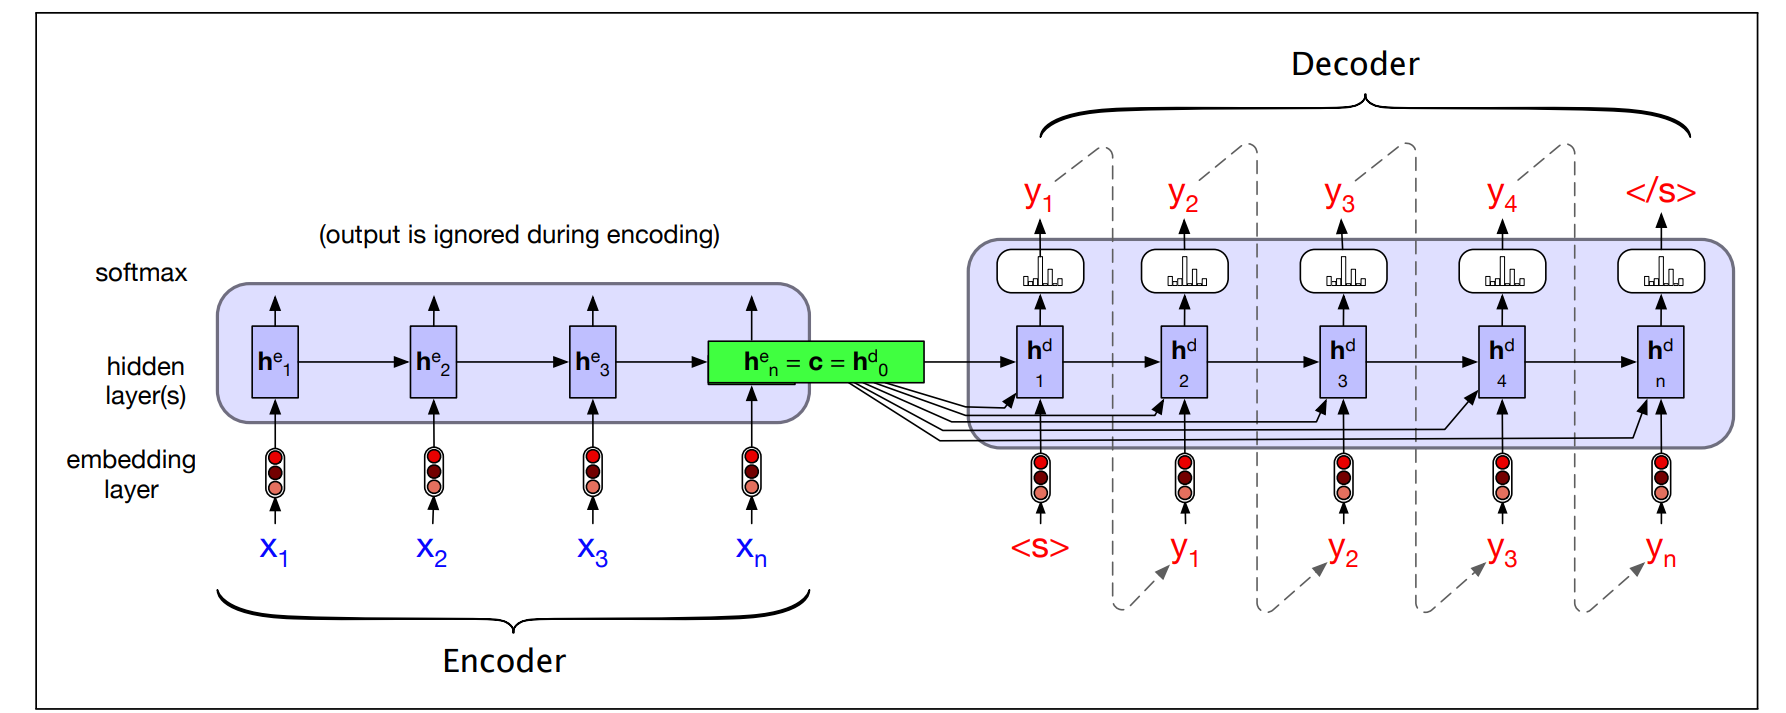

# Training an Encoder–Decoder Architecture

## Key Considerations
1. **Keep the architecture diagram in mind**  
   - Training involves both **encoder and decoder together**.  
   - If studied separately, the process can be confusing.

2. **Dataset Requirement**  
   - For machine translation, we need **parallel datasets**.  
   - These datasets contain two aligned columns:  
     - **Source language sentences** (e.g., English)  
     - **Target language sentences** (e.g., Hindi)

### Example Parallel Data
| English Sentence          | Hindi Translation   |
|----------------------------|---------------------|
| Jump                       | छलांग              |
| Hello                      | नमस्ते              |
| I am at home               | मैं घर पर हूं        |

Such pairs allow supervised training, as both **input** and **expected output** are available.

---

## Step-by-Step Training Example
Let’s assume a small toy dataset with only **two sentence pairs**:

- **English → Hindi**
  1. "Think about it" → "सोच लो"  
  2. "Come in" → "अंदर आ जाओ"

---

### Step 1: Tokenization
- Break sentences into **tokens**.  
- Example:
  - "Think about it" → ["Think", "about", "it"]  
  - "Come in" → ["Come", "in"]  
  - Hindi translations:  
    - "सोच लो" → ["सोच", "लो"]  
    - "अंदर आ जाओ" → ["अंदर", "आ", "जाओ"]

---

### Step 2: Numerical Representation
Neural networks cannot understand text directly → convert tokens into numbers.

#### One-Hot Encoding
- Build a **vocabulary list** for each language.
- Example English vocab: {Think, about, it, Come, in}  
- Example Hindi vocab: {सोच, लो, अंदर, आ, जाओ}  

#### Special Tokens
- Add two additional symbols for target (output) sequences:  
  - **<START>** – Marks beginning of output.  
  - **<END>** – Marks end of output.  
- These must also be one-hot encoded.  

Thus, if Hindi vocab had 5 words, total output vocab becomes **7 tokens** (5 + START + END).  

---

### Step 3: Encoding Sentences
- Each word is replaced with its one-hot vector.  
- Example:
  - "Think" → [1, 0, 0, 0, 0]  
  - "about" → [0, 1, 0, 0, 0]  
  - "it" → [0, 0, 1, 0, 0]  

- Similarly for Hindi:  
  - "सोच" → [0, 1, 0, 0, 0, 0, 0]  
  - "लो" → [0, 0, 1, 0, 0, 0, 0]  
  - <START> → [1, 0, 0, 0, 0, 0, 0]  
  - <END> → [0, 0, 0, 0, 0, 0, 1]  

---

## Result
- Now both **input and output sequences are numeric**.  
- These sequences can be fed into the **encoder–decoder network** for supervised training.  


# Training Process of Encoder–Decoder Architecture

## Step 1: Forward Propagation

- The architecture consists of:
  - **Encoder LSTM**
  - **Decoder LSTM**
- Initially, weights and biases are **randomly initialized**.

### Encoder Side
- Input: Source sentence (e.g., "Think about it")
- Each token is passed step by step:
  - At each time step, the encoder updates its hidden states (`h_t`) and cell states (`c_t`).
  - After the last token, the **final hidden and cell states** are obtained → these act as **context vectors**.
- These context vectors are passed to the decoder.

### Decoder Side
- Input: Context vectors + special token `<START>`
- Decoder LSTM generates outputs step by step.
- Each output passes through:
  - A **Dense Layer**
  - A **Softmax Layer**
- The Softmax layer has as many units as the vocabulary size of the target language.  
  - Example: If target vocab = 7 tokens, Softmax has 7 nodes.
- Softmax outputs a probability distribution over possible tokens.  
- The predicted token = the one with **maximum probability**.

---

## Step 2: Teacher Forcing

- In theory, the decoder’s next input should be its **own previous prediction**.  
- Problem: Early in training, predictions are often **wrong**, causing error propagation.  
- Solution: **Teacher Forcing**  
  - During training, the **true token** (from dataset) is fed at the next time step, not the model’s wrong prediction.  
  - This accelerates convergence and stabilizes learning.

---

## Step 3: Example of Predictions

- At first time step: model predicted "लो" instead of "सोच".  
- At second time step: predicted "जाओ" instead of "लो".  
- At third time step: predicted `<END>` which was **correct**.  
- Observations:  
  - Wrong predictions → higher loss  
  - Correct predictions → lower loss

---

## Step 4: Loss Calculation

- The task is **multi-class classification** at each time step.  
- Appropriate loss: **Categorical Cross-Entropy**  
  \[
  L = - \sum_{i=1}^{V} y_i \cdot \log(\hat{y}_i)
  \]  
  - \(V\): vocabulary size  
  - \(y_i\): true one-hot vector  
  - \(\hat{y}_i\): predicted probability

- Loss is calculated for **each time step**, then summed or averaged.  
- Example:  
  - Step 1 → wrong prediction → higher loss  
  - Step 2 → wrong prediction → higher loss  
  - Step 3 → correct prediction → low loss  
- Total loss = sum of step-wise losses.

---

## Step 5: Backpropagation

- Once loss is computed, backpropagation begins.
- Two main steps:
  1. **Gradient Calculation**  
     - Derivatives of loss w.r.t. each trainable parameter are computed.  
     - Parameters include LSTM weights, Dense layer weights, Softmax weights.  
     - Gradients indicate how much each parameter contributed to the error and in which direction to adjust.
  2. **Parameter Update**  
     - Gradients are applied using an optimizer (e.g., SGD, Adam, RMSProp).  
     - Learning rate controls the step size of updates.

---

## Step 6: Iterative Training

- After weights are updated:
  - Next training example is passed through the network.  
  - Forward propagation → loss → backpropagation → weight update.  
- Repeated across all dataset examples, model gradually learns correct mappings.

---

## Final Outcome

- After sufficient iterations:
  - The encoder–decoder architecture learns to map source sentences to target translations.  
  - Training completes when model loss converges to a low value and predictions become accurate.


# Prediction (Inference) using Encoder–Decoder

## Overview
- After training, all **weights and biases are fixed** (no further updates).  
- The model can now be used for **prediction** on new input sentences.  
- Example input: `"Think about it"`  
- Goal: Translate into Hindi using the trained encoder–decoder.

---

## Step 1: Encoder Processing
1. **Tokenization**  
   - The input sentence is tokenized: ["Think", "about", "it"]  
   - Each token is converted into its **one-hot encoded vector**.

2. **Feeding into Encoder**  
   - Word `"Think"` → passed through encoder → hidden state updated.  
   - Word `"about"` → processed → hidden state updated further.  
   - Word `"it"` → final update → encoder outputs **final hidden state (h<sub>T</sub>)** and **cell state (c<sub>T</sub>)**.  
   - These form the **context vector**, summarizing the input sentence.

---

## Step 2: Decoder Initialization
- Decoder requires:
  - **Context vector** (from encoder)  
  - **Special token `<START>`** (as first input)  

- Decoder LSTM generates an output → passed through **Dense + Softmax** → probability distribution over target vocabulary.  

---

## Step 3: Generating Tokens Step by Step
1. **First Time Step**
   - Input: `<START>` token + context vector  
   - Decoder outputs probability distribution.  
   - The token with highest probability = `"सोच"`  
   - Prediction = `"सोच"`

2. **Second Time Step**
   - Input: previously predicted token `"सोच"` (not teacher forcing, but model’s own output).  
   - Decoder updates hidden state and predicts again.  
   - Highest probability token = `"जाओ"`  
   - Prediction = `"जाओ"`

3. **Third Time Step**
   - Input: previous prediction `"जाओ"`  
   - Decoder generates probabilities.  
   - Highest probability token = `"लो"`  
   - Prediction = `"लो"`

4. **Fourth Time Step**
   - Input: previous prediction `"लो"`  
   - Decoder outputs highest probability token = `<END>`  
   - Process stops here.

---

## Step 4: Final Output
- Concatenating predicted tokens:  

- `"सोच जाओ लो"`

- This is the translation produced by the model for input `"Think about it"`.

---

## Observations
- The translation here is **not accurate**.  
- Errors happen if:
- Training data was insufficient.  
- Model did not learn correct alignments.  
- Still, the process demonstrates the exact way predictions happen in inference mode:
- No teacher forcing  
- No backpropagation  
- No weight updates  
- The model simply **generates output tokens sequentially**, until `<END>` is predicted.

---

## Summary
- **Training phase**: Teacher forcing + loss calculation + backpropagation.  
- **Prediction phase**:  
- Encoder creates context vector.  
- Decoder generates tokens sequentially, using its own previous outputs.  
- Stops when `<END>` token is predicted.  


# Improvements to Basic Encoder–Decoder

## First Improvement: Using Embeddings

### Problem with One-Hot Encoding
- In the basic model, each input word was represented using **one-hot encoding**.  
- This works fine for a very small vocabulary (e.g., 5 words).  
- But in real-world datasets:
  - Vocabulary size can reach **tens or hundreds of thousands**.  
  - One-hot vectors become extremely high-dimensional (e.g., 100,000+).  
  - Sparse representation: mostly zeros, inefficient to process.  
- Hence, one-hot encoding is not practical for large-scale NLP tasks.

---

### Solution: Word Embeddings
- **Embeddings** provide **low-dimensional dense representations** of words.  
- Instead of a 100,000-dimensional one-hot vector, each word can be mapped to a **dense vector** of, say, 3–300 dimensions.  
- Example:
  - `"Think"` → [0.21, -0.85, 0.47]  
  - `"About"` → [0.56, 0.03, -0.91]  
  - `"It"` → [0.09, 0.66, 0.12]  

#### Advantages:
1. **Low-Dimensional** → reduces computation.  
2. **Dense Representation** → very few zeros, efficient storage.  
3. **Context Capture** → embeddings learn semantic meaning, unlike one-hot encoding.  
4. Can be used in both **encoder and decoder**.  
   - Encoder: Each input word passes through an embedding layer before LSTM.  
   - Decoder: Each predicted token also goes through an embedding layer before feeding into LSTM.  

---

### How to Use Embeddings
1. **Pre-trained Embeddings**  
   - Examples: **Word2Vec**, **GloVe**, **FastText**.  
   - Already trained on large corpora.  
   - Can be used directly or fine-tuned on your dataset.  

2. **Trainable Embeddings**  
   - Add an **embedding layer** in your model (e.g., in Keras, `Embedding()` layer).  
   - During training, the embedding weights are updated along with the rest of the model.  
   - Captures dataset-specific word meanings and context.  

---

### Final Encoder–Decoder with Embeddings
- **Encoder Block**  
  - Input sentence (e.g., `"Nice to meet you"`) → Embedding Layer → LSTM → Context Vector.  

- **Decoder Block**  
  - `<START>` token → Embedding Layer → LSTM → Softmax Layer → Predicted word.  
  - Process repeats until `<END>` token is generated.  

- Embedding layers replace one-hot encoding in **both encoder and decoder**, making the model more efficient and context-aware.  

---

✅ This is the **first improvement** to the basic encoder–decoder:  
We replace one-hot encoding with **word embeddings** to achieve dense, low-dimensional, and meaningful word representations.


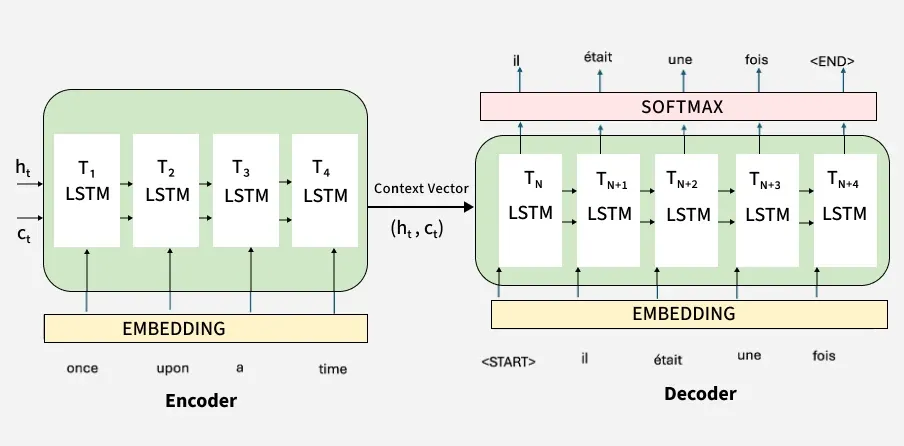

# Improvements in Encoder–Decoder (Seq2Seq) using LSTMs

## 1. From Single-Layer to Deep LSTM
- Traditionally, Seq2Seq models used a **single-layer LSTM** in both encoder and decoder.  
- Improvement: **stack multiple LSTM layers** on top of each other → known as **Deep LSTM**.  
- Each LSTM layer:
  - Updates hidden state forward in time.  
  - Passes processed representation upward to the next LSTM layer.  

### Benefits of Deep LSTM
1. **Better handling of long-term dependencies**  
   - Single LSTM struggles with very long sequences (e.g., paragraphs).  
   - Stacked layers capture more context and improve translation of long sentences.  

2. **Hierarchical representation learning**  
   - Lower layers → capture local/word-level patterns.  
   - Middle layers → capture sentence-level meaning.  
   - Upper layers → capture paragraph/document-level context.  

   Example: *“The phone’s battery is bad but the overall phone is great”*  
   - Lower LSTM: identifies word-level grammar (singular/plural, verbs).  
   - Middle LSTM: extracts sentence-level meaning.  
   - Higher LSTM: understands paragraph-level sentiment.  

3. **Increased model capacity**  
   - More parameters (weights & biases) → model can capture fine-grained variations.  
   - Leads to better generalization if sufficient training data is provided.  
   - Helps in handling input variations effectively.  

👉 The original paper (*Sutskever et al., 2014*) used a **4-layer Deep LSTM** in both encoder and decoder, achieving significantly better results than single-layer LSTMs.

---

## 2. Reversing Input Sequences
- Trick: reverse the input sequence before feeding to the encoder.  
  - Example: Instead of feeding *“think about it”*, feed *“it about think”*.  

### Why it helps
- Reduces the distance between corresponding source and target words.  
- Example: *“think” → “सोच”* is closer in reversed input, so gradients propagate more easily.  
- Works best for language pairs where **initial words carry most context** (e.g., English → French).  

⚠ Limitation:  
- Does not always help. For languages where context is spread more evenly, reversing input may not improve performance.

---

## 3. Original Paper Details (Sutskever et al., 2014)

- **Task:** English → French machine translation.  
- **Architecture:** Encoder–Decoder using **Deep LSTMs** (4 layers, 1000 units each).  
- **Word Embeddings:** 1000-dimensional vectors.  
- **Output Layer:** Softmax over target vocabulary.  
- **Dataset:** WMT’14  
  - ~12M sentence pairs  
  - ~304M English words, ~348M French words  
  - Vocabulary: ~160K English words, ~80K French words  
  - Out-of-vocabulary words mapped to a special **UNK token**.  
- **Special Tokens:** Used an **End-of-Sentence (EOS)** symbol instead of start/end markers.  
- **Performance:**  
  - Achieved **BLEU score = 34.8**, outperforming phrase-based translation systems of that time.  

---

## Key Takeaways
- **Deep LSTM improves translation** by capturing long-term dependencies and hierarchical representations.  
- **Reversing input sequences** can improve gradient flow and translation quality for certain language pairs.  
- **Large-scale training (12M sentences)** with **high-dimensional embeddings and deep architecture** was crucial for achieving state-of-the-art results.  
